Note: Since the competition was invite only this notebook can't be submitted. 

#  SMS Spam Detection with Naive Bayes

### Description

**What this is**

A from-scratch spam/ham classifier built on the classic SMS Spam Collection dataset (5,572 
text messages, ~87% ham / 13% spam). This is my second Naive Bayes project — the first was 
sentiment analysis on IMDB reviews — so the goal here was to apply the same techniques to a 
noisier, shorter-form, imbalanced text problem and see what changes.

**How I did it**

- **Cleaned the raw data**: recovered messages that got split across extra CSV columns by 
  stray commas, removed duplicates, and normalized emoticons, SMS slang (`u` → `you`, 
  `2` → `to`), and contractions.
- **Preserved negation words** (`not`, `no`, `never`) during stopword removal — the default 
  English stopword list strips these out, which quietly destroys sentiment-flipping signal 
  like "not free" vs. "free."
- **Engineered spam-specific placeholders** for phone numbers, long digit runs, and URLs, 
  since raw digits and links are strong spam indicators that generic text cleaning would 
  otherwise throw away.
- **Vectorized** with `CountVectorizer`/`TfidfVectorizer` using unigrams + bigrams 
  (`ngram_range=(1,2)`), so phrases like "not free" are captured as a single feature, not two 
  independent words.
- **Trained and tuned four Naive Bayes variants** — Bernoulli, Multinomial (raw counts), 
  Multinomial (TF-IDF), and Complement NB — each with a coarse-to-fine grid search over the 
  smoothing parameter `alpha`, validated on a held-out stratified split.
- **Selected the final model on precision and F1, not accuracy** — with 87% ham, a model that 
  predicts "ham" for everything would already score 87% accuracy while catching zero spam, so 
  accuracy alone is close to meaningless here.

**Best result**

**BernoulliNB** (unigrams + bigrams, tuned smoothing) came out on top:

| Metric | Score |
|---|---|
| Accuracy | 0.9835 |
| Precision | 0.9826 |
| Recall | 0.8828 |
| F1 Score | 0.9300 |

Bernoulli won on precision and F1 specifically — for spam filtering, a false positive (a real 
message flagged as spam) is more costly than a false negative (spam slipping through), so a 
model that misses a bit more spam in exchange for almost never blocking a real message is the 
right tradeoff here, not necessarily the highest-accuracy option.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import kagglehub
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv", encoding="latin-1")
print(df.shape)
df.head()

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [4]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [5]:
df[['Unnamed: 2','v2']][df['Unnamed: 2'].notna()][:5]

,Unnamed: 2,v2
95,PO Box 5249,Your free ringtone is waiting to be collected....
281,the person is definitely special for u..... B...,\Wen u miss someone
444,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...
671,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",SMS. ac sun0819 posts HELLO:\You seem cool
710,"this wont even start........ Datz confidence..""",Height of Confidence: All the Aeronautics prof...


In [6]:
df[['Unnamed: 3','v2']][df['Unnamed: 3'].notna()][:5]

,Unnamed: 3,v2
95,"MK17 92H. 450Ppw 16""",Your free ringtone is waiting to be collected....
281,why to miss them,\Wen u miss someone
899,"MK17 92H. 450Ppw 16""",Your free ringtone is waiting to be collected....
1038,GE,"Edison has rightly said, \A fool can ask more ..."
2170,"U NO THECD ISV.IMPORTANT TOME 4 2MORO\""""",\CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER...


In [7]:
df[['Unnamed: 4','v2']][df['Unnamed: 4'].notna()][:5]

,Unnamed: 4,v2
281,"just Keep-in-touch\"" gdeve..""",\Wen u miss someone
1038,"GNT:-)""","Edison has rightly said, \A fool can ask more ..."
2255,"Never comfort me with a lie\"" gud ni8 and swe...",I just lov this line: \Hurt me with the truth
3525,"CALL 2MWEN IM BK FRMCLOUD 9! J X\""""",\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...
4668,"one day these two will become FREINDS FOREVER!""","When I was born, GOD said, \Oh No! Another IDI..."


**Hypothesis:** These Unnamed: 2/3/4 values exist because a stray comma inside the message text caused pandas to split it into extra columns, simply dropping them would silently truncate the original message for those rows. Merging them back preserves the full text.

In [8]:
df.fillna("",inplace=True)

In [9]:
df.isna().sum()

v1            0
v2            0
Unnamed: 2    0
Unnamed: 3    0
Unnamed: 4    0
dtype: int64

In [10]:
df['message'] = (df['v2'] + " " + df['Unnamed: 2'] + " " + df['Unnamed: 3'] + " " + df['Unnamed: 4']).str.strip()
df['label'] = df['v1']
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,message,label
0,ham,"Go until jurong point, crazy.. Available only ...",,,,"Go until jurong point, crazy.. Available only ...",ham
1,ham,Ok lar... Joking wif u oni...,,,,Ok lar... Joking wif u oni...,ham
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,,,,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,ham,U dun say so early hor... U c already then say...,,,,U dun say so early hor... U c already then say...,ham
4,ham,"Nah I don't think he goes to usf, he lives aro...",,,,"Nah I don't think he goes to usf, he lives aro...",ham


In [11]:
data = df[['message','label']].copy()

## EDA

label
ham     4825
spam     747
Name: count, dtype: int64


<Axes: xlabel='label'>

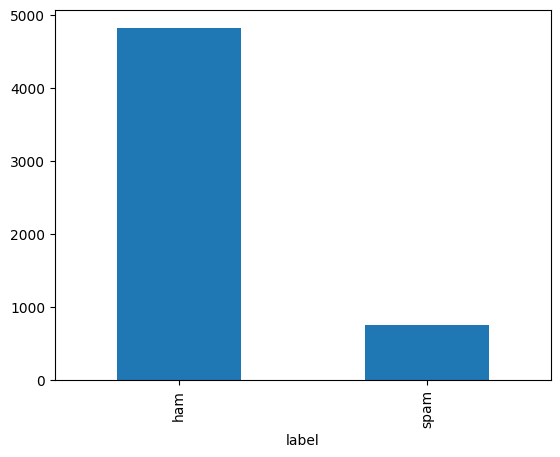

In [12]:
print(data['label'].value_counts())
data['label'].value_counts().plot(kind='bar')

In [13]:
data[['message']].duplicated().sum()

np.int64(414)

In [14]:
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)
data[['message']].duplicated().sum()

np.int64(0)

There are 414 duplicate messages which contribute to ~0.07 of dataset. Since its very small and duplicate rows. We can drop them.

<Axes: >

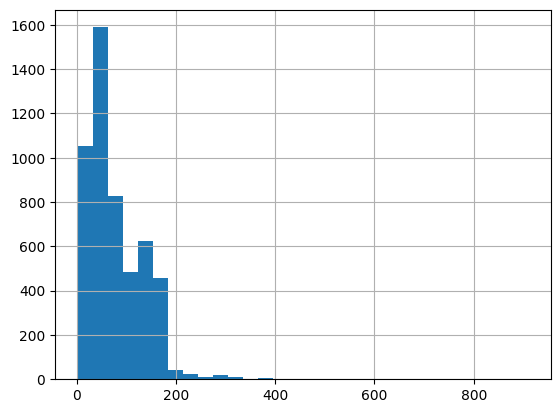

In [15]:
data['message'].str.len().hist(bins=30)

In [16]:
data['label'].value_counts()

label
ham     4516
spam     642
Name: count, dtype: int64

In [17]:
print(data['message'][data['message'].str.len() <10].count())
data['message'][data['message'].str.len() <10][:10]

31


129     I'm home.
256           Yup
271      Thanx...
279       Okie...
282          Ok..
620      Thank u!
764      Beerage?
937       Where @
1233        Ok...
1350      Oh ok..
Name: message, dtype: object

The peak near 0-5 is caused by small mostly non spam text like "Yup" , "Ok.." or ":-)" etc..  

In [18]:
print(data['message'][data['message'].str.len() >100].count())
data['message'][data['message'].str.len() > 100][:10]

1568


0     Go until jurong point, crazy.. Available only ...
2     Free entry in 2 a wkly comp to win FA Cup fina...
5     FreeMsg Hey there darling it's been 3 week's n...
7     As per your request 'Melle Melle (Oru Minnamin...
8     WINNER!! As a valued network customer you have...
9     Had your mobile 11 months or more? U R entitle...
10    I'm gonna be home soon and i don't want to tal...
11    SIX chances to win CASH! From 100 to 20,000 po...
12    URGENT! You have won a 1 week FREE membership ...
13    I've been searching for the right words to tha...
Name: message, dtype: object

In [19]:
print(data['message'][data['message'].str.len() >300].count())
data['message'][data['message'].str.len() > 300][:10]

32


152     You are everywhere dirt, on the floor, the win...
696     Height of Confidence: All the Aeronautics prof...
817     Sir, I have been late in paying rent for the p...
1057    For me the love should start with attraction.i...
1317    &lt;#&gt; %of pple marry with their lovers... ...
1341    Storming msg: Wen u lift d phne, u say \HELLO\...
1461    Hey sweet, I was wondering when you had a mome...
1526    How to Make a girl Happy? It's not at all diff...
1532    I was wondering if it would be okay for you to...
1763    Dude. What's up. How Teresa. Hope you have bee...
Name: message, dtype: object

Most of the messages with >100 character lenth is mostly spam messages. But messages with character length >300 is less likely to be spam. Since, Spam texts tend to run long (cramming in an offer + a callback number + T&Cs)

> **Hypothesis:** message can be a good indicator of spam or ham. 

In [20]:
data['char_len'] = data['message'].str.len()
data['word_count'] = data['message'].str.split(" ").str.len()

data.groupby('label')[['char_len', 'word_count']].describe()

char_len                                                           \
         count        mean        std   min    25%    50%    75%    max   
label                                                                     
ham     4516.0   71.024801  56.705369   2.0   34.0   53.0   92.0  910.0   
spam     642.0  137.876947  30.075653  13.0  132.0  148.5  157.0  224.0   

      word_count                                                       
           count       mean        std  min    25%   50%   75%    max  
label                                                                  
ham       4516.0  14.338795  11.287128  1.0   7.00  11.0  19.0  171.0  
spam       642.0  23.707165   5.972499  2.0  21.25  25.0  28.0   35.0

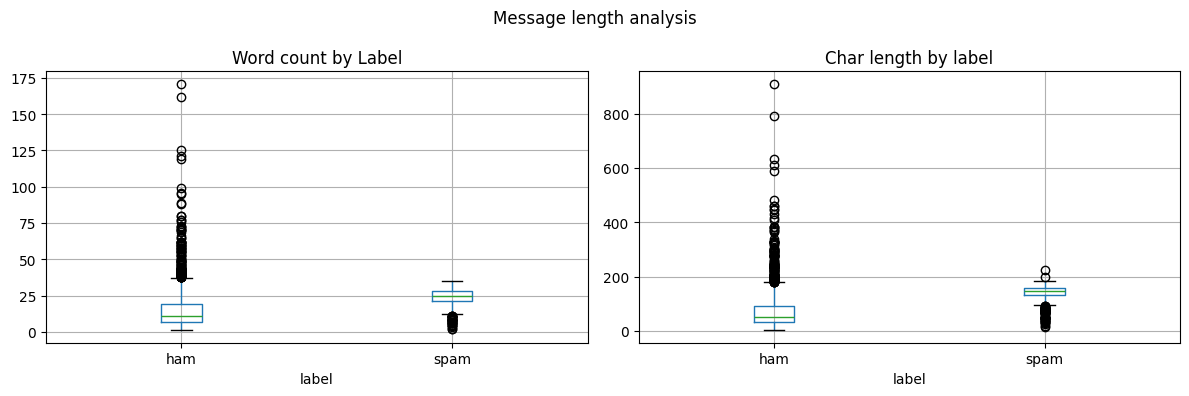

In [21]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
data.boxplot(column='word_count', by='label', ax=axes[0])
axes[0].set_title("Word count by Label")
data.boxplot(column='char_len', by="label", ax=axes[1])
axes[1].set_title("Char length by label")
plt.suptitle("Message length analysis")
plt.tight_layout()
plt.show()

<Axes: xlabel='char_len', ylabel='Probability'>

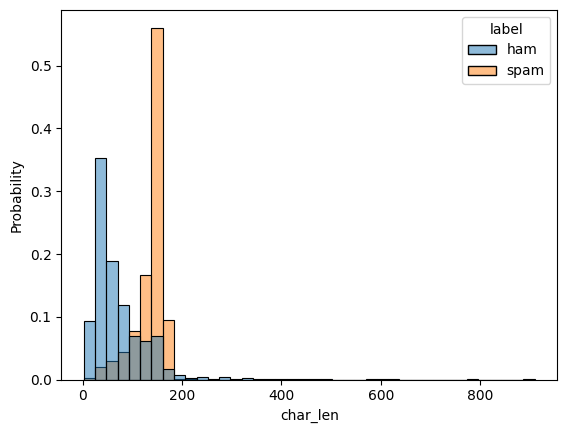

In [22]:
sns.histplot(data=data, x='char_len', hue='label', stat='probability', common_norm=False, alpha=0.5, bins=40)

<Axes: xlabel='word_count', ylabel='Probability'>

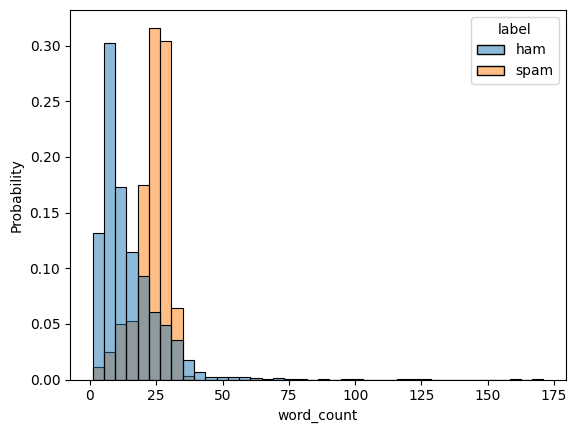

In [23]:
sns.histplot(data=data, x='word_count', hue='label', stat='probability', common_norm=False, alpha=0.5, bins=40)

### Summary
- The column "Unnamed: 2", "Unnamed: 3" and "Unnamed: 4" are merged into the message column because they were probabily seperated in csv because of extra comma in the message. 
- Duplicates and empty string rows are dropped.

**Message Length Analysis:**

- The character length and word count box plot analysis tells us the same thing. Ham class is well spread but has Q1 - Q3 below the Spam class but spam class is more norrowly spread.

- Ham messages are concentrated at short lengths, peaking around 5-10 words, with over 40% of ham messages falling in that range before quickly tapering off, though a long thin tail extends out to 100+ words.
- Spam messages  cluster in a much narrower band, peaking sharply around 25-30 words, with very few spam messages falling below 15 or above 40 words, suggesting a fairly consistent template length.
- The two distributions overlap only partially (the gray region), roughly between 15-35 words, meaning word count alone can separate a large portion of messages: very short messages are overwhelmingly ham, and messages near 25-30 words are disproportionately spam, making it a useful feature for classification even though it can't perfectly distinguish the overlapping middle range.

- There is a meaningful overlap between the two distributions (roughly 15-35 words), so length alone would misclassify a decent chunk of messages if used as the sole predictor. And the histogram only shows correlation/visual separation, it doesn't quantify how predictive length actually is. So, we can conclude that the hypothesis is partially correct.

> Insight: Try adding a new message length column and use GNB to predict the message length and add both the results in the end. 

### Word Analysis and Data Cleaning:

- Emoticon Mappping
- Slang Mapping 
- Stop words filter

In [24]:
word_pattern = r"\b[a-z]+(?:'[a-z]+)?\b"

EMOTICON_MAP = {
    r":-?\)": " emo_smile ", r":-?\(": " emo_sad ",
    r";-?\)": " emo_wink ",  r":-?d": " emo_laugh ",
    r":-?p": " emo_tongue ", r"<3": " emo_heart ",
}

SLANG_MAP = {
    "u": "you", "ur": "your", "r": "are", "thx": "thanks", "thanx": "thanks",
    "pls": "please", "plz": "please", "gr8": "great", "b4": "before",
    "l8r": "later", "txt": "text", "msg": "message", "n" : "and", "s":"yes",
    "2":"to", "4":"for"
}


CONTRACTIONS = {
    "won't": "will not",     "can't": "cannot",
    "shan't": "shall not",   "ain't": "am not",
    "don't": "do not",       "doesn't": "does not",   "didn't": "did not",
    "isn't": "is not",       "aren't": "are not",     "wasn't": "was not",
    "weren't": "were not",   "haven't": "have not",   "hasn't": "has not",
    "hadn't": "had not",     "wouldn't": "would not", "couldn't": "could not",
    "shouldn't": "should not",
    "it's": "it is",         "that's": "that is",     "there's": "there is",
    "what's": "what is",     "he's": "he is",         "she's": "she is",
    "i'm": "i am",           "you're": "you are",     "we're": "we are",
    "they're": "they are",
    "i've": "i have",        "you've": "you have",    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",        "you'll": "you will",    "we'll": "we will",
    "i'd": "i would",        "you'd": "you would",
}

REMOVE_FROM_STOP_WORDS = {"not", "no", "never", "nor", "none"}

In [25]:
from collections import Counter
import re

def get_word_counts(reviews, n=20):
    words = []
    for text in reviews:
        words.extend(re.findall(word_pattern, text.lower()))
    return Counter(words).most_common(n)

In [26]:

print("After normalizing the emoticons and slang words\n")

print("Top words - Ham messages:")
print(get_word_counts(data[data['label'] == "ham"]['message']))

print("\nTop words - Spam messages:")
print(get_word_counts(data[data['label'] == "spam"]['message']))

After normalizing the emoticons and slang words

Top words - Ham messages:
[('i', 2201), ('you', 1798), ('to', 1481), ('the', 1062), ('a', 972), ('u', 917), ('and', 826), ('in', 762), ('me', 732), ('my', 679), ('is', 655), ('it', 570), ('for', 481), ('that', 481), ('of', 478), ('have', 426), ('so', 421), ('but', 420), ('are', 398), ('not', 393)]

Top words - Spam messages:
[('to', 584), ('a', 325), ('call', 302), ('you', 251), ('your', 237), ('free', 190), ('for', 181), ('the', 181), ('now', 162), ('or', 156), ('u', 141), ('is', 139), ('txt', 132), ('on', 121), ('from', 120), ('ur', 119), ('have', 113), ('stop', 111), ('text', 108), ('mobile', 105)]


- `u` `txt` `ur` are message slangs and since its the same as `you` `text` and `your` We can map all the slangs to it's actual word. So, It gets removed during the stop word filtering. 

In [27]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english')) - REMOVE_FROM_STOP_WORDS

def remove_stopwords(text):
    tokens = text.split(" ")
    filtered = [t for t in tokens if t not in stop_words]
    return " ".join(filtered)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
def normalize_emoticons_and_slang(text):
    text = text.lower()
    tokens = text.split(" ")
    for pattern, token in EMOTICON_MAP.items():
        text = re.sub(pattern, token, text)
    for slang, full in SLANG_MAP.items():
        text = re.sub(rf'\b{re.escape(slang)}\b', full, text)
    return text

_pattern = re.compile(
    r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b",
    flags=re.IGNORECASE,
)

def expand_contractions(text):
    return _pattern.sub(lambda m: CONTRACTIONS[m.group(0).lower()], text.lower())

# Func converts all "'s"  nto "is" So, that slang convertion does not convert it as "yes"  
def expand_is_contraction(text): 
    return re.sub(r"(\w+)'s\b", r"\1 is", text)

In [29]:
data['message_clean'] = data['message'].apply(normalize_emoticons_and_slang).apply(remove_stopwords)

print("After normalizing the emoticons and slang words\n")

print("Top words - Ham messages:")
print(get_word_counts(data[data['label'] =="ham"]['message_clean']))

print("\nTop words - Spam messages:")
print(get_word_counts(data[data['label'] == "spam"]['message_clean']))

After normalizing the emoticons and slang words

Top words - Ham messages:
[('not', 393), ('get', 297), ('you', 296), ('gt', 288), ('lt', 287), ('no', 274), ('ok', 256), ('go', 244), ('got', 227), ('know', 226), ('like', 224), ('good', 217), ('come', 214), ('time', 193), ('call', 192), ('love', 185), ('please', 183), ('day', 178), ('me', 167), ('going', 164)]

Top words - Spam messages:
[('call', 302), ('text', 240), ('free', 190), ('stop', 111), ('mobile', 105), ('reply', 96), ('claim', 95), ('now', 83), ('www', 81), ('message', 80), ('prize', 79), ('you', 79), ('get', 70), ('cash', 64), ('new', 64), ('no', 61), ('send', 59), ('please', 58), ('urgent', 57), ('uk', 53)]


The top words "lt" , "gt" and "www" are html tag's "<>" as "&gt;" nd "&lt;" which got cleaned up and the "www" is just some link's first part which can be used to map the links.

Let's remove the "lt" and "gt" since they are not meaningful to our classifier. 

In [30]:
empty_string = ""
space_placeholder = " "
html_tag_pattern = r'\b(gt|lt)\b'
url_pattern = r'www\.\S+'
url_placehulder = " urlplaceholder "
phone_num_pattern = r'\b\d{7,}\b'
phone_num_placeholder = " phonenum "
num_pattern = r'\d{3,}'
num_placeholder = " num "
special_char_pattern = r'[^a-z0-9_\s]'
white_space_pattern = r'\s+'

In [31]:
def clean_message(text):
    text = re.sub(html_tag_pattern, empty_string, text)
    text = re.sub(url_pattern, space_placeholder , text)
    text = re.sub(phone_num_pattern, phone_num_placeholder, text)
    text = re.sub(num_pattern, num_placeholder, text)

    text = expand_is_contraction(text)
    text = normalize_emoticons_and_slang(text)
    text = expand_contractions(text)
    
    text = re.sub(special_char_pattern, space_placeholder, text)   # strip leftover symbols/punctuation like #$@%
    text = re.sub(white_space_pattern, space_placeholder, text).strip() 
    
    text = remove_stopwords(text)
    return text


data['message_clean'] = data['message'].apply(clean_message)

print("After normalizing the emoticons, numbers, URLs, HTML tag leftovers and slang words\n")

print("Top words - Ham messages:")
print(get_word_counts(data[data['label'] == "ham"]['message_clean']))

print("\nTop words - Spam messages:")
print(get_word_counts(data[data['label'] == "spam"]['message_clean']))

After normalizing the emoticons, numbers, URLs, HTML tag leftovers and slang words

Top words - Ham messages:
[('not', 668), ('get', 297), ('no', 275), ('ok', 256), ('go', 244), ('got', 227), ('know', 226), ('like', 224), ('good', 217), ('come', 214), ('time', 193), ('call', 192), ('love', 186), ('day', 185), ('please', 183), ('going', 164), ('want', 161), ('lor', 159), ('one', 159), ('home', 156)]

Top words - Spam messages:
[('num', 967), ('phonenum', 362), ('call', 305), ('text', 242), ('free', 190), ('stop', 111), ('mobile', 105), ('reply', 96), ('claim', 95), ('p', 95), ('message', 82), ('prize', 79), ('get', 70), ('cash', 64), ('new', 64), ('no', 61), ('send', 59), ('please', 58), ('urgent', 57), ('nokia', 56)]


- We can see that "urlplaceholders" , "phonenum" and "num" apprear more in spam than in ham.
- After cleaning the text message we can find clear trends in the top words in the respctive clasees. Where the ham class has normal eveyday text words like "get", "ok", "go", "got" etc. Spam class has more advertisement or contact related words like "num" , "phonenum", "call", "text", "free" etc. 

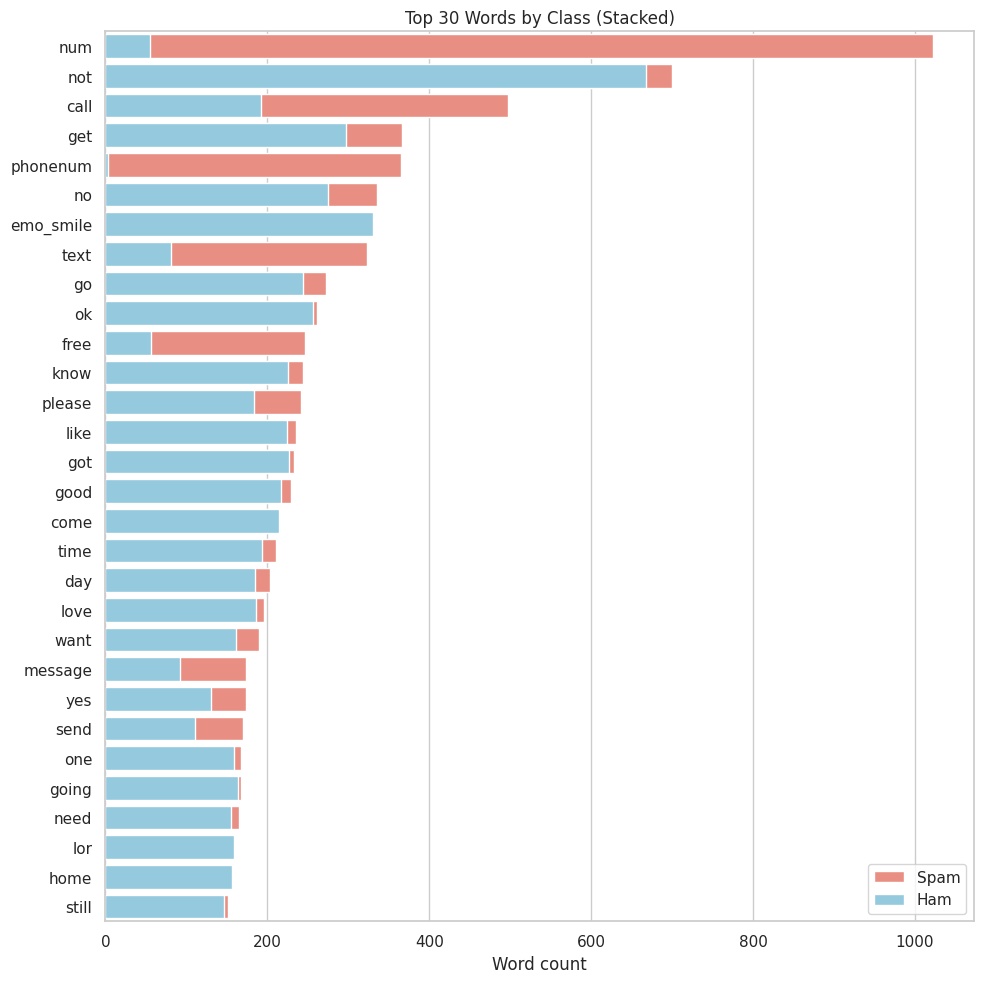

In [32]:
sns.set_theme(style="whitegrid")

def get_word_counts_counter(texts, stopwords=stop_words): # new fn 
    all_text = ' '.join(texts).split()
    filtered = [w for w in all_text if w not in stopwords]
    return Counter(filtered) 

ham_counts  = get_word_counts_counter(data[data['label'] == 'ham']['message_clean'])
spam_counts = get_word_counts_counter(data[data['label'] == 'spam']['message_clean'])

all_words = set(ham_counts) | set(spam_counts)
word_df = pd.DataFrame({
    'word':list(all_words),
    "ham": [ham_counts.get(w,0) for w in all_words],
    "spam": [spam_counts.get(w,0) for w in all_words],
})
word_df['total'] = word_df['ham'] + word_df['spam']
top30 = word_df.sort_values('total', ascending=False).head(30)

plt.figure(figsize=(10, 10))
sns.barplot(data=top30, y='word', x='total', color='salmon',   label='Spam')
sns.barplot(data=top30, y='word', x='ham',   color='skyblue',  label='Ham')
plt.legend()
plt.xlabel('Word count')
plt.ylabel('')
plt.title('Top 30 Words by Class (Stacked)')
plt.tight_layout()
plt.show()

## Preprocessing

In [33]:
data.head()
d = data[['message_clean','label']].copy()
d = d.rename(columns={'message_clean': 'message'})
d['label'] = d['label'].map({"spam":1,"ham":0})
data = d
data.head()

,message,label
0,go jurong point crazy available bugis great wo...,0
1,ok lar joking wif oni,0
2,free entry wkly comp win fa cup final tkts 21s...,1
3,dun say early hor c already say,0
4,nah not think goes usf lives around though,0


Since the spam class is minority the majority of words are from ham class. But we can still see that some words are apperaring more in spam class.

In [34]:
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(d,test_size=0.2,random_state=67,stratify=data['label'])
train, val = train_test_split(train_val,test_size=0.125,random_state=67,stratify=train_val['label'])

print(train.shape , test.shape, val.shape) # 70 - 10 - 20 split

(3610, 2) (1032, 2) (516, 2)


In [35]:
X_train = train['message']
y_train = train['label']
X_val = val['message']
y_val = val['label']
X_test = test['message']
y_test = test['label']

**Note:**

 TfidfVectorizer weighting each word based on how rare it is across all messages.

`TF-IDF(word, doc) = TF(word, doc) × IDF(word)`

Term Frequency, TF(word, doc), is simply how often that word appears in that specific message (just a raw count, like CountVectorizer gives you).

Inverse Document Frequency, IDF(word), measures how rare that word is across the whole dataset, and is typically calculated as:

`IDF(word) = log( total number of documents / number of documents containing that word )`

So, a word that appears in almost every message gets a small IDF (close to 0), while a word that appears in only a few messages gets a large IDF.

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vectorizer_b = CountVectorizer(ngram_range=(1,2), stop_words=list(stop_words), min_df=3, binary=True)
vectorizer_m = CountVectorizer(ngram_range=(1,2), stop_words=list(stop_words), min_df=3)
vectorizer_t = TfidfVectorizer(ngram_range=(1,2), stop_words=list(stop_words), min_df=3)

X_train_b = vectorizer_b.fit_transform(X_train)
X_val_b   = vectorizer_b.transform(X_val)

X_train_m = vectorizer_m.fit_transform(X_train)
X_val_m   = vectorizer_m.transform(X_val)

X_train_t = vectorizer_t.fit_transform(X_train)
X_val_t   = vectorizer_t.transform(X_val)

print(X_train_b.shape, X_train_m.shape, X_train_t.shape)

(3610, 2778) (3610, 2778) (3610, 2778)


In [37]:
feature_names = vectorizer_b.get_feature_names_out()
pd.DataFrame(feature_names)

,0
0,00
1,00 sub
2,02
3,02 06
4,03
...,...
2773,yr
2774,yrs
2775,yummy
2776,yun


# Model Training

In [38]:
# Helper Func 
def model_fine_tune(nb_model, X_train, y_train, X_val, y_val, alpha_arr):
    result_arr = [] 
    for a in alpha_arr: 
        model = nb_model(alpha=a)
        model.fit(X_train,y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        result_arr.append((a,acc))
        print(f"alpha: {a:6f} val_accuracy: {acc:4f}")
    return result_arr

def hyper_param_tuning(model, model_name, X_train, y_train, X_val, y_val, coarse_param):
    coarse_results = []
    
    coarse_results = model_fine_tune(model, X_train, y_train, X_val, y_val, coarse_param)
    
    best_coarse_alpha = max(coarse_results, key=lambda x: x[1])[0]
    print("\nBest coarse alpha:", best_coarse_alpha)
    
    # Fine search: narrow range around the best coarse value
    fine_alphas = np.linspace(best_coarse_alpha / 5, best_coarse_alpha * 5, 15)
    
    fine_results =  model_fine_tune(model, X_train, y_train, X_val, y_val, fine_alphas)
    best_alpha = max(fine_results, key=lambda x: x[1])[0]
    best_acc = max(fine_results, key=lambda x: x[1])[1]
    print(f"\nBest fine-tuned alpha for {model_name}: {best_alpha:.4f} (val_accuracy={best_acc:.4f})")
    
    final_model = model(alpha=best_alpha)
    final_model.fit(X_train, y_train)
    return final_model, best_alpha

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

def confusion_matrix_plot(y_test,y_preds):
    cm = confusion_matrix(y_test, y_preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

def print_metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred), "\n\n")
    
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
    return accuracy_score(y_test, y_pred)

## Bernoulli's Naive Bayes 

In [40]:
from sklearn.naive_bayes import BernoulliNB

coarse_alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
final_bnb, best_alpha_b = hyper_param_tuning(BernoulliNB, "Bernoulli's NB Cnt Vct :", X_train_b, y_train, X_val_b, y_val, coarse_alphas)

alpha: 0.001000 val_accuracy: 0.980620
alpha: 0.010000 val_accuracy: 0.984496
alpha: 0.100000 val_accuracy: 0.986434
alpha: 1.000000 val_accuracy: 0.984496
alpha: 5.000000 val_accuracy: 0.934109
alpha: 10.000000 val_accuracy: 0.895349
alpha: 50.000000 val_accuracy: 0.875969
alpha: 100.000000 val_accuracy: 0.875969

Best coarse alpha: 0.1
alpha: 0.020000 val_accuracy: 0.986434
alpha: 0.054286 val_accuracy: 0.986434
alpha: 0.088571 val_accuracy: 0.986434
alpha: 0.122857 val_accuracy: 0.986434
alpha: 0.157143 val_accuracy: 0.986434
alpha: 0.191429 val_accuracy: 0.986434
alpha: 0.225714 val_accuracy: 0.986434
alpha: 0.260000 val_accuracy: 0.986434
alpha: 0.294286 val_accuracy: 0.986434
alpha: 0.328571 val_accuracy: 0.986434
alpha: 0.362857 val_accuracy: 0.984496
alpha: 0.397143 val_accuracy: 0.984496
alpha: 0.431429 val_accuracy: 0.984496
alpha: 0.465714 val_accuracy: 0.984496
alpha: 0.500000 val_accuracy: 0.984496

Best fine-tuned alpha for Bernoulli's NB Cnt Vct :: 0.0200 (val_accuracy=0

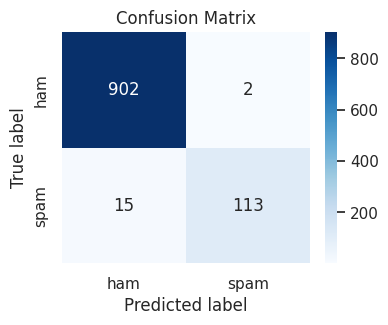

In [41]:
X_test_b = vectorizer_b.transform(X_test)

preds_b = final_bnb.predict(X_test_b)

confusion_matrix_plot(y_test, preds_b)

In [42]:
best_acc_b = print_metrics(y_test, preds_b)

Accuracy: 0.9835271317829457
Precision: 0.9826086956521739
Recall: 0.8828125
F1 Score: 0.9300411522633745 


              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       904
        spam       0.98      0.88      0.93       128

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032



## Multinomial Naive  - Count Vectorization 

In [43]:
from sklearn.naive_bayes import MultinomialNB

coarse_alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
final_mnb, best_alpha_m = hyper_param_tuning(MultinomialNB, "Multinomial NB - CV :", X_train_m, y_train, X_val_m, y_val, coarse_alphas)

alpha: 0.001000 val_accuracy: 0.972868
alpha: 0.010000 val_accuracy: 0.974806
alpha: 0.100000 val_accuracy: 0.976744
alpha: 1.000000 val_accuracy: 0.982558
alpha: 5.000000 val_accuracy: 0.986434
alpha: 10.000000 val_accuracy: 0.982558
alpha: 50.000000 val_accuracy: 0.976744
alpha: 100.000000 val_accuracy: 0.976744

Best coarse alpha: 5
alpha: 1.000000 val_accuracy: 0.982558
alpha: 2.714286 val_accuracy: 0.982558
alpha: 4.428571 val_accuracy: 0.986434
alpha: 6.142857 val_accuracy: 0.986434
alpha: 7.857143 val_accuracy: 0.986434
alpha: 9.571429 val_accuracy: 0.984496
alpha: 11.285714 val_accuracy: 0.982558
alpha: 13.000000 val_accuracy: 0.984496
alpha: 14.714286 val_accuracy: 0.984496
alpha: 16.428571 val_accuracy: 0.986434
alpha: 18.142857 val_accuracy: 0.986434
alpha: 19.857143 val_accuracy: 0.986434
alpha: 21.571429 val_accuracy: 0.984496
alpha: 23.285714 val_accuracy: 0.984496
alpha: 25.000000 val_accuracy: 0.984496

Best fine-tuned alpha for Multinomial NB - CV :: 4.4286 (val_accura

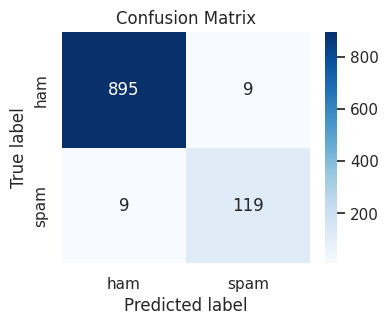

In [44]:
X_test_m = vectorizer_m.transform(X_test)
preds_m = final_mnb.predict(X_test_m)
confusion_matrix_plot(y_test, preds_m)

In [45]:
best_acc_m = print_metrics(y_test, preds_m)

Accuracy: 0.9825581395348837
Precision: 0.9296875
Recall: 0.9296875
F1 Score: 0.9296875 


              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       904
        spam       0.93      0.93      0.93       128

    accuracy                           0.98      1032
   macro avg       0.96      0.96      0.96      1032
weighted avg       0.98      0.98      0.98      1032



# Multinomial Naive Bayes - TI-IDF Vectorization 

In [46]:
coarse_alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
final_tnb, best_alpha_t = hyper_param_tuning(MultinomialNB, "Multinomial NB - TI-IDF :", X_train_t, y_train, X_val_t, y_val, coarse_alphas)

alpha: 0.001000 val_accuracy: 0.972868
alpha: 0.010000 val_accuracy: 0.972868
alpha: 0.100000 val_accuracy: 0.972868
alpha: 1.000000 val_accuracy: 0.970930
alpha: 5.000000 val_accuracy: 0.934109
alpha: 10.000000 val_accuracy: 0.891473
alpha: 50.000000 val_accuracy: 0.875969
alpha: 100.000000 val_accuracy: 0.875969

Best coarse alpha: 0.001
alpha: 0.000200 val_accuracy: 0.972868
alpha: 0.000543 val_accuracy: 0.972868
alpha: 0.000886 val_accuracy: 0.972868
alpha: 0.001229 val_accuracy: 0.972868
alpha: 0.001571 val_accuracy: 0.972868
alpha: 0.001914 val_accuracy: 0.972868
alpha: 0.002257 val_accuracy: 0.972868
alpha: 0.002600 val_accuracy: 0.972868
alpha: 0.002943 val_accuracy: 0.972868
alpha: 0.003286 val_accuracy: 0.972868
alpha: 0.003629 val_accuracy: 0.972868
alpha: 0.003971 val_accuracy: 0.972868
alpha: 0.004314 val_accuracy: 0.972868
alpha: 0.004657 val_accuracy: 0.972868
alpha: 0.005000 val_accuracy: 0.972868

Best fine-tuned alpha for Multinomial NB - TI-IDF :: 0.0002 (val_accurac

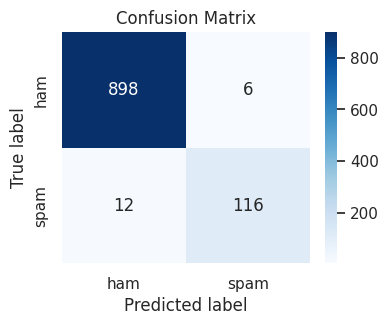

In [47]:
X_test_t = vectorizer_t.transform(X_test)
preds_t = final_tnb.predict(X_test_t)
confusion_matrix_plot(y_test, preds_t)

In [48]:
best_acc_t = print_metrics(y_test,preds_t)

Accuracy: 0.9825581395348837
Precision: 0.9508196721311475
Recall: 0.90625
F1 Score: 0.928 


              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       904
        spam       0.95      0.91      0.93       128

    accuracy                           0.98      1032
   macro avg       0.97      0.95      0.96      1032
weighted avg       0.98      0.98      0.98      1032



##  Complement Naive Bayes - TF-IDF

Complement Naive Bayes instead of learning what spam looks like directly, it learns what "everything that is NOT spam" (the complement) looks like, using the much larger and more stable ham data, and then classifies a message as spam if it looks like a poor match for that complement. TF-IDF downweights very common, uninformative words, which pairs naturally with the complement-based weighting scheme.

In [49]:
from sklearn.naive_bayes import ComplementNB 

coarse_alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
final_cnb, best_alpha_c = hyper_param_tuning(ComplementNB, "Complement NB - TI-IDF :", X_train_t, y_train, X_val_t, y_val, coarse_alphas)

alpha: 0.001000 val_accuracy: 0.967054
alpha: 0.010000 val_accuracy: 0.968992
alpha: 0.100000 val_accuracy: 0.972868
alpha: 1.000000 val_accuracy: 0.972868
alpha: 5.000000 val_accuracy: 0.968992
alpha: 10.000000 val_accuracy: 0.967054
alpha: 50.000000 val_accuracy: 0.963178
alpha: 100.000000 val_accuracy: 0.963178

Best coarse alpha: 0.1
alpha: 0.020000 val_accuracy: 0.968992
alpha: 0.054286 val_accuracy: 0.970930
alpha: 0.088571 val_accuracy: 0.970930
alpha: 0.122857 val_accuracy: 0.972868
alpha: 0.157143 val_accuracy: 0.972868
alpha: 0.191429 val_accuracy: 0.972868
alpha: 0.225714 val_accuracy: 0.970930
alpha: 0.260000 val_accuracy: 0.970930
alpha: 0.294286 val_accuracy: 0.972868
alpha: 0.328571 val_accuracy: 0.972868
alpha: 0.362857 val_accuracy: 0.972868
alpha: 0.397143 val_accuracy: 0.972868
alpha: 0.431429 val_accuracy: 0.970930
alpha: 0.465714 val_accuracy: 0.970930
alpha: 0.500000 val_accuracy: 0.970930

Best fine-tuned alpha for Complement NB - TI-IDF :: 0.1229 (val_accuracy=0

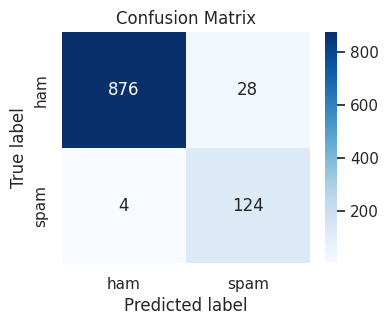

In [50]:
X_test_c = vectorizer_t.transform(X_test)
preds_c = final_cnb.predict(X_test_c)
confusion_matrix_plot(y_test, preds_c)

In [51]:
best_acc_c = print_metrics(y_test,preds_c)

Accuracy: 0.9689922480620154
Precision: 0.8157894736842105
Recall: 0.96875
F1 Score: 0.8857142857142857 


              precision    recall  f1-score   support

         ham       1.00      0.97      0.98       904
        spam       0.82      0.97      0.89       128

    accuracy                           0.97      1032
   macro avg       0.91      0.97      0.93      1032
weighted avg       0.97      0.97      0.97      1032



## Final Model:

In [52]:
print(f"BernoulliNB best val accuracy:   {best_acc_b:.4f}")
print(f"MultinomialNB best val accuracy: {best_acc_m:.4f}")
print(f"MultinomialNB TI-IDF best val accuracy: {best_acc_t:.4f}")
print(f"ComplementNB TI-IDF best val accuracy: {best_acc_c:.4f}")

BernoulliNB best val accuracy:   0.9835
MultinomialNB best val accuracy: 0.9826
MultinomialNB TI-IDF best val accuracy: 0.9826
ComplementNB TI-IDF best val accuracy: 0.9690


**Final Model Selection and Thoughts:** 
- Bernoulli's : Precision: 0.9826 Recall: 0.882 F1 Score: 0.9300 
- Multinomial + Count vect :  Precision: 0.9296875 Recall: 0.92968 F1 Score: 0.92968
- Multinoial + TF IDF : Precision: 0.9508196 Recall: 0.90625 F1 Score: 0.928 
- Complement NB : Precision: 0.8157894 Recall: 0.96875 F1 Score: 0.885714285


**Bernoulli** takes both of your top two priority metrics — highest precision and highest F1. It only loses on recall, which is exactly the metric we agreed you're allowed to sacrifice. This isn't really a tradeoff decision, it's a clean win on your own stated criteria.

The interesting one is ComplementNB — and it's a good lesson, not a bug. It has the best recall by a wide margin (0.9688) — doing exactly what it's built for, catching more spam than anything else. But it pays for that with by far the worst precision (0.8158) — meaning it's flagging real messages as spam far more often than the others. That's ComplementNB's known bias-correction behavior working as designed: it pushes harder toward catching the minority class.

Now, Let's train the model on both the train and val data using the best alpha and predict test data. 

In [53]:
X_test.head()

3780                           cool text
3360    ok come home vl nice meet v chat
948            yup thk e shop closes lor
1396                  ok askd knw tht no
3327         prepare pounded every night
Name: message, dtype: object

In [54]:
vectorizer = CountVectorizer(ngram_range=(1,2), stop_words=list(stop_words), min_df=3, binary=True)

X_train_f = vectorizer.fit_transform(train_val['message'])
y_train_f = train_val['label']

X_test_f = vectorizer.transform(X_test)

final_model = BernoulliNB(alpha=best_alpha_b)
final_model.fit(X_train_f, y_train_f)
y_pred_f = final_model.predict(X_test_f)

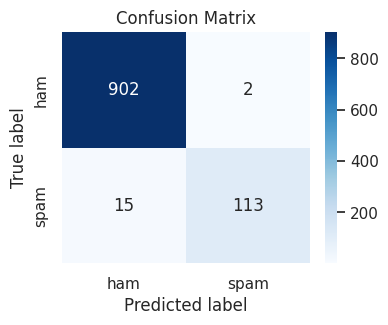

In [55]:
confusion_matrix_plot(y_test, y_pred_f)

In [56]:
print_metrics(y_test,y_pred_f)

Accuracy: 0.9835271317829457
Precision: 0.9826086956521739
Recall: 0.8828125
F1 Score: 0.9300411522633745 


              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       904
        spam       0.98      0.88      0.93       128

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032



0.9835271317829457